# Импорты библиотек

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Добавьте необходимые библиотеки здесь

# Чтение данных

In [2]:
df_path = r"C:\Python\Project workshop\marketplace.csv"
df = pd.read_csv('marketplace.csv')
df.head()

,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return
0,user_000000,12,2025-03-22,2024-08-17,browser_00,2025-03-22,0.0,85.329559,0.0
1,user_000001,1,2025-05-05,2025-05-15,browser_01,2025-05-20,0.0,21.819124,0.0
2,user_000002,5,2025-01-19,2025-01-23,browser_02,2025-02-20,0.3,194.612980,485.0
3,user_000003,3,2025-03-15,2023-09-05,browser_02,NaN,0.0,138.780814,0.0
4,user_000004,1,2025-05-05,2025-05-14,browser_00,2025-05-11,0.0,16.334507,0.0


# Анализ дат

In [3]:
# Извлекаю даты
date_cols = ['first_login', 'reg_dt', 'first_buy']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Проверяю аномалии (флаг)
# Регистрация должна быть раньше или совпадать с датой первого входа/покупки
df['dt_anomalies'] = df['reg_dt'] > df['first_login']

# Считаю количество, среднее и медиану
# False - нормальные, True - аномальные
print(df['dt_anomalies'].value_counts())

dt_anomalies
False    16738
True      8597
Name: count, dtype: int64


Сравнение дат первого входа First Login
                              min                  50%                  max
dt_anomalies                                                               
False         2024-09-21 00:00:00  2025-03-23 00:00:00  2025-07-26 00:00:00
True          2024-09-21 00:00:00  2025-03-19 00:00:00  2025-07-23 00:00:00


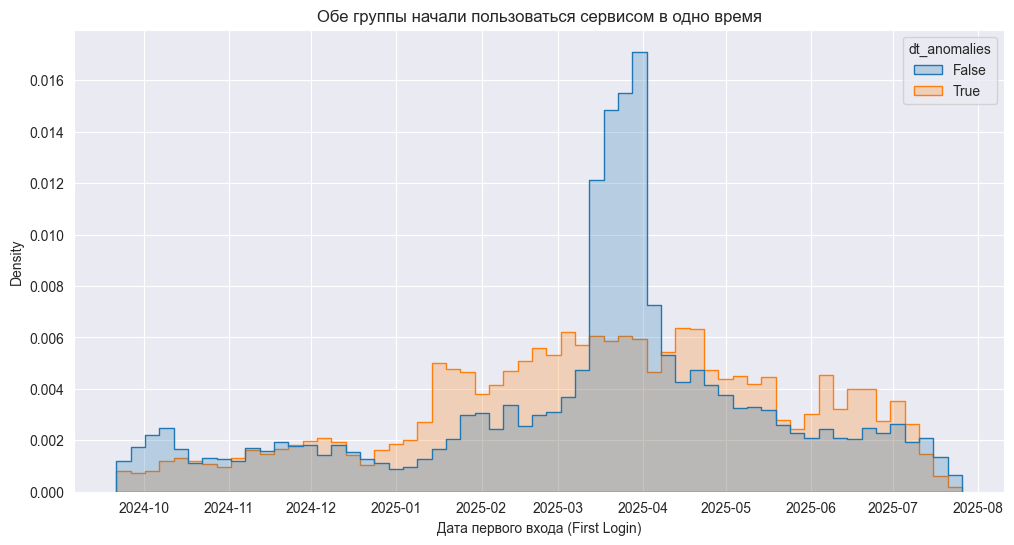

In [4]:
# Гипотеза о том, что это архивные данные, не подтвердилась
print("Сравнение дат первого входа First Login")
print(df.groupby('dt_anomalies')['first_login'].describe()[['min', '50%', 'max']])

# График
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='first_login', hue='dt_anomalies', element="step", common_norm=False, stat='density')
plt.title('Обе группы начали пользоваться сервисом в одно время')
plt.xlabel('Дата первого входа (First Login)')
plt.show()

In [17]:
# Разница между регистрацией и входом
# У нормальных она <= 0 у аномальных она положительная

df['date_diff'] = (df['reg_dt'] - df['first_login']).dt.days
anomalous_users = df[df['dt_anomalies'] == True]

print("\nЗадержки регистрации в днях")
print(anomalous_users['date_diff'].value_counts().head(5))


Задержки регистрации в днях
date_diff
1.0    795
2.0    791
3.0    713
4.0    701
5.0    640
Name: count, dtype: int64


Нормальные | Всего: 15901 | Гостей (куп. до рег.): 2848 (17.9%) | Мин. время: -129 дн.
Аномальные | Всего: 8460 | Гостей (куп. до рег.): 4695 (55.5%) | Мин. время: -20 дн.


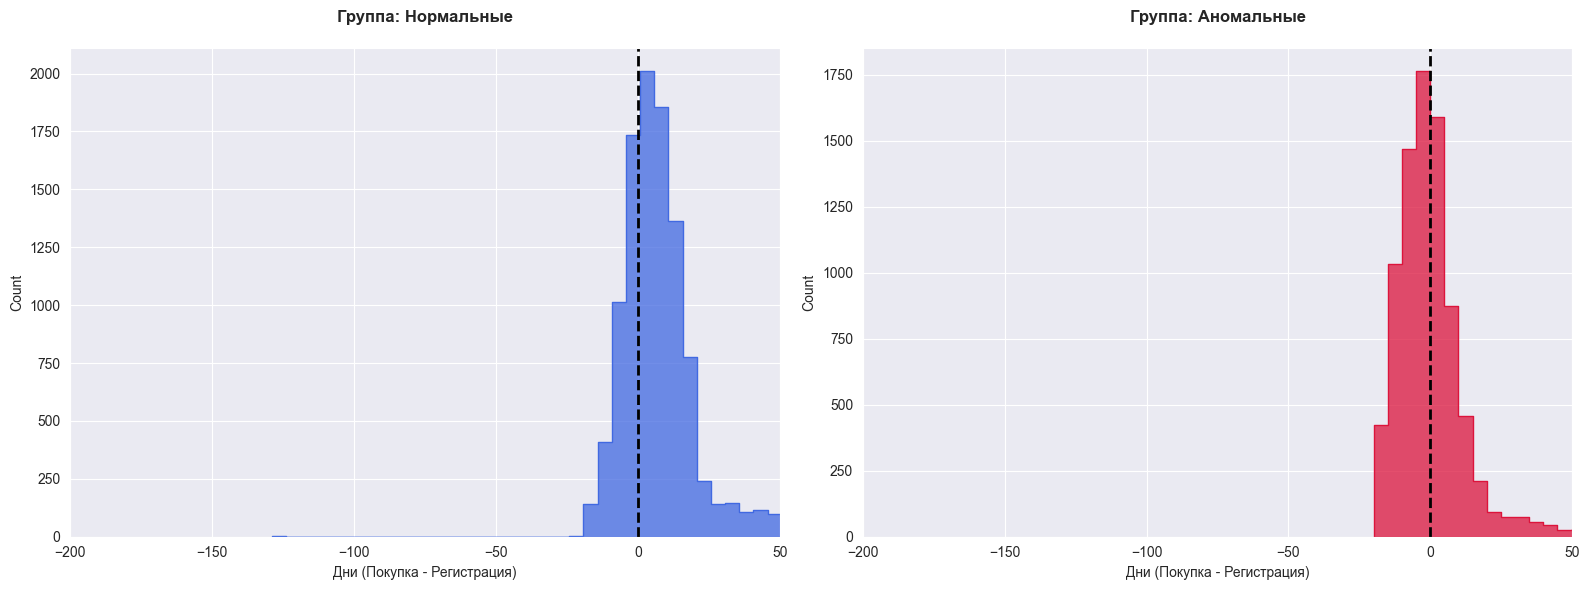

In [19]:
# Беру тех, у кого есть first_buy
buyers = df.dropna(subset=['first_buy']).copy()

# Считаем разницу покупка - регистрация
buyers['ttfb_original'] = (buyers['first_buy'] - buyers['reg_dt']).dt.days

# Разделяем на группы
normal_buyers = buyers[buyers['dt_anomalies'] == False]
anom_buyers = buyers[buyers['dt_anomalies'] == True]

# Расчет статистики по группам
def get_stats(data, name):
    count = len(data)
    neg_count = (data['ttfb_original'] < 0).sum()
    pct = (neg_count / count) * 100
    min_val = data['ttfb_original'].min()
    return f"{name}\nВсего: {count}\nГостей (куп. до рег.): {neg_count} ({pct:.1f}%)\nМин. время: {min_val} дн."

stats_norm = get_stats(normal_buyers, "Нормальные")
stats_anom = get_stats(anom_buyers, "Аномальные")

print(stats_norm.replace('\n', ' | '))
print(stats_anom.replace('\n', ' | '))

# Графики
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# нормальные
sns.histplot(normal_buyers['ttfb_original'], binwidth=5, ax=axes[0], color='royalblue', element="step")
axes[0].set_title(f'Группа: Нормальные\n', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Дни (Покупка - Регистрация)')
axes[0].axvline(0, color='black', linestyle='--', linewidth=2, label='Дата регистрации')
axes[0].set_xlim(-200, 50)

# аномальные
sns.histplot(anom_buyers['ttfb_original'], binwidth=5, ax=axes[1], color='crimson', element="step")
axes[1].set_title(f'Группа: Аномальные\n', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Дни (Покупка - Регистрация)')
axes[1].axvline(0, color='black', linestyle='--', linewidth=2, label='Дата регистрации')
axes[1].set_xlim(-200, 50)

plt.tight_layout()
plt.show()

Выводы: аномалии с датами (регистрация позже покупки) около ~30% базы. Скорее всего, это не баг, а фича. Предположение: используется две БД для гостевых и зарегистрированных аккаунтов.

Предположение:
- Не удалять и не исправлять даты, чтобы не искажать историю
- Ввести сегментацию: добавить флаг is_guest для случаев, где first_buy < reg_dt
- Анализировать поведение гостевых и зарегистрированных пользователей раздельно